<!--
CSI-6-ARI Week 7 Tutorial
Supervised Learning (Classification) and Unsupervised Learning
-->


<style>
  :root{
    --bg:#0b1320;
    --fg:#eef3fb;
    --muted:#b9c6dc;
    --card:#ffffff;
    --line:#e6eaf2;
    --soft:#f6f8fb;
    --info:#eef6ff;
    --warn:#fff7e6;
    --task:#fff0f3;
    --ok:#eefaf0;
    --infoLine:#cfe5ff;
    --warnLine:#ffe1a6;
    --taskLine:#ffd1dc;
    --okLine:#bfe8c7;
  }

  /* Consistent notebook typography (match Week 1 exactly) */
  .markdown, .markdown p, .markdown li, .markdown div { font-size: 16px; line-height: 1.65; }
  h1 { font-size: 36px; margin: 0 0 12px 0; }
  h2 { font-size: 24px; margin: 22px 0 10px 0; }
  h3 { font-size: 19px; margin: 16px 0 8px 0; }

  .hero{
    padding:20px 22px;
    border-radius:18px;
    background:var(--bg);
    color:var(--fg);
    border:1px solid rgba(255,255,255,0.12);
  }
  .hero .subtitle{margin-top:10px;font-size:18px;font-weight:650;color:var(--muted);}
  .hero .meta{margin-top:10px;font-size:14px;color:var(--muted);}

  .grid{display:grid;grid-template-columns:1fr 1fr;gap:12px;margin-top:14px;}
  .card{
    padding:14px 16px;
    border-radius:16px;
    background:var(--card);
    border:1px solid var(--line);
    box-shadow:0 1px 0 rgba(20,30,50,0.04);
  }
  .card h3{margin:0 0 10px 0;font-size:18px;}

  .box{padding:14px 16px;border-radius:16px;border:1px solid var(--line);background:var(--soft);margin:12px 0;}
  .box.info{background:var(--info);border-color:var(--infoLine);}
  .box.warn{background:var(--warn);border-color:var(--warnLine);}
  .box.task{background:var(--task);border-color:var(--taskLine);}
  .box.ok{background:var(--ok);border-color:var(--okLine);}

  .boxtitle{font-weight:850;font-size:18px;margin:0 0 8px 0;display:flex;gap:10px;align-items:center;}

  .badge{
    width:28px;height:28px;
    border-radius:9px;
    display:inline-flex;align-items:center;justify-content:center;
    font-weight:900;font-size:16px;
    border:1px solid rgba(0,0,0,0.08);
  }
  .b-info{background:#dbeafe;color:#1d4ed8;}
  .b-warn{background:#ffedd5;color:#c2410c;}
  .b-task{background:#ffe4e6;color:#be123c;}
  .b-ok{background:#dcfce7;color:#166534;}

  code{background:#f1f5f9;border-radius:6px;padding:1px 6px;}
  details{border:1px dashed #cbd5e1;border-radius:14px;padding:10px 12px;background:#fbfdff;}
  summary{cursor:pointer;font-weight:850;font-size:16px;}
</style>

<div class="hero">
  <h1><b>CSI-6-ARI, Week 7 Tutorial</b></h1>
  <div class="subtitle">Supervised Learning (Classification) and Unsupervised Learning</div>
</div>

<div class="grid">
  <div class="card">
    <h3><b>🎯 Learning outcomes</b></h3>
    <ul>
      <li>Build a <b>KNN classifier</b> for a classification task, using a proper <code>train_test_split</code>.</li>
      <li>Apply <b>feature scaling</b> (standardisation) and explain why it matters for distance-based models.</li>
      <li>Evaluate classification using <b>accuracy</b> and a <b>confusion matrix</b>, interpret common failure modes.</li>
      <li>Select hyperparameters (e.g., <code>k</code>) using <b>cross-validation</b>, and implement <b>pipelines</b> to avoid leakage.</li>
      <li>Fit <b>K-means clustering</b>, choose <code>k</code> using an elbow-style heuristic, and interpret cluster structure.</li>
    </ul>
  </div>
  <div class="card">
    <h3><b>🧭 How to use this notebook</b></h3>
    <ul>
      <li>Run cells top-to-bottom. Later sections assume earlier variables exist.</li>
      <li>Do not skip preprocessing steps, some results will be misleading if scaling is omitted.</li>
      <li>Exercises use an empty code cell. Complete it before opening the answer.</li>
      <li>Answers are in collapsible boxes with explanation.</li>
    </ul>
  </div>
</div>



<div class="box warn">
  <div class="boxtitle"><span class="badge b-warn">⚠️</span> Important</div>
  <ul>
    <li>We keep this notebook intentionally simple, fewer abstractions, fewer helper functions.</li>
    <li>Focus on the algorithmic ideas first (splits, scaling, evaluation, clustering intuition), then tidy the code later.</li>
    <li>When you tune hyperparameters, always do it via cross-validation inside a pipeline to avoid optimistic results.</li>
  </ul>
</div>


## 1) <b>✅ KNN classification (k-nearest neighbours)</b>

<div class="box">
  <div class="boxtitle"><span class="badge b-info">🧭</span> Core idea</div>
  <ul>
    <li>
      <b>KNN (k-nearest neighbours)</b> is a <b>non-parametric</b> classifier, it does not learn a fixed set of weights like linear models.
      Instead, it stores the training data and makes predictions by looking up the <b>k most similar</b> training points to a new sample.
    </li>
    <li>
      “Nearest” is defined via a <b>distance metric</b>, most commonly <b>Euclidean distance</b> for continuous features.
      The predicted class is the <b>majority vote</b> among the neighbours (sometimes with <b>distance weighting</b>, where closer neighbours count more).
    </li>
    <li>
      The hyperparameter <code>k</code> controls the <b>bias–variance trade-off</b>:
      <ul>
        <li><b>Small k</b> (e.g., 1–3) can fit noise, it tends to have <b>high variance</b> and may overfit.</li>
        <li><b>Larger k</b> smooths the decision boundary, it tends to have <b>higher bias</b> and may underfit.</li>
      </ul>
    </li>
    <li>
      Because KNN relies on distances, <b>feature scaling is essential</b>.
      If one feature has a larger numeric range, it can dominate the distance computation and distort “nearness”.
      In this tutorial, we will use <b>standardisation</b> (zero mean, unit variance) before fitting KNN.
    </li>
  </ul>
</div>



<div class="box warn">
  <div class="boxtitle"><span class="badge b-warn">⚠️</span> Practical cautions (what can go wrong)</div>
  <ul>
    <li>
      <b>Data leakage:</b> never scale the full dataset before splitting.
      Fit the scaler on the <b>training set only</b>, then transform train and test.
      A <b>pipeline</b> is the safest way to do this.
    </li>
    <li>
      <b>Class imbalance:</b> if one class is much more common, a naïve model can look “accurate” while performing poorly on the minority class.
      We will inspect a <b>confusion matrix</b> (and optionally precision/recall) to see what is actually happening.
    </li>
    <li>
      <b>Choice of k:</b> do not pick <code>k</code> by eye using the test set.
      Use <b>cross-validation</b> (e.g., GridSearchCV) on the training set, then evaluate once on the held-out test set.
    </li>
  </ul>
</div>


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Importing Dataset



<div class="box info">
  <div class="boxtitle"><span class="badge b-info">🧪</span> Dataset context (gene expression levels)</div>
  <ul>
    <li>
      To understand KNN for classification, we will work with a simple dataset representing <b>gene expression levels</b>.
      Gene expression levels are often reported as a <b>ratio</b> between the expression of a <b>target gene</b> (gene of interest)
      and one or more <b>reference genes</b> (often “housekeeping” genes) to normalise measurements across samples.
    </li>
    <li>
      This dataset is <b>synthetic</b> and deliberately designed to illustrate both strengths and limitations of KNN:
      <ul>
        <li><b>Strength:</b> KNN can model <b>non-linear</b> class boundaries without explicitly fitting a parametric curve.</li>
        <li><b>Limitation:</b> KNN can struggle when classes overlap, when there is noise, or when scaling is incorrect.</li>
      </ul>
    </li>
    <li>
      In practical bioinformatics, expression data can be noisy and high-dimensional, so we must be careful about
      <b>data splitting</b>, <b>scaling</b>, and <b>evaluation</b> to avoid misleading results.
    </li>
  </ul>
  <p style="margin-top:10px">
    More information (optional reading), gene expression:
    <a href="https://www.sciencedirect.com/topics/biochemistry-genetics-and-molecular-biology/gene-expression-level" target="_blank" rel="noopener noreferrer">
      ScienceDirect topic page
    </a>
  </p>
</div>

In [ ]:
df = pd.read_csv('gene_expression.csv')

In [ ]:
df.head()

,Gene One,Gene Two,Cancer Present
0,4.3,3.9,1
1,2.5,6.3,0
2,5.7,3.9,1
3,6.1,6.2,0
4,7.4,3.4,1


<Axes: xlabel='Gene One', ylabel='Gene Two'>

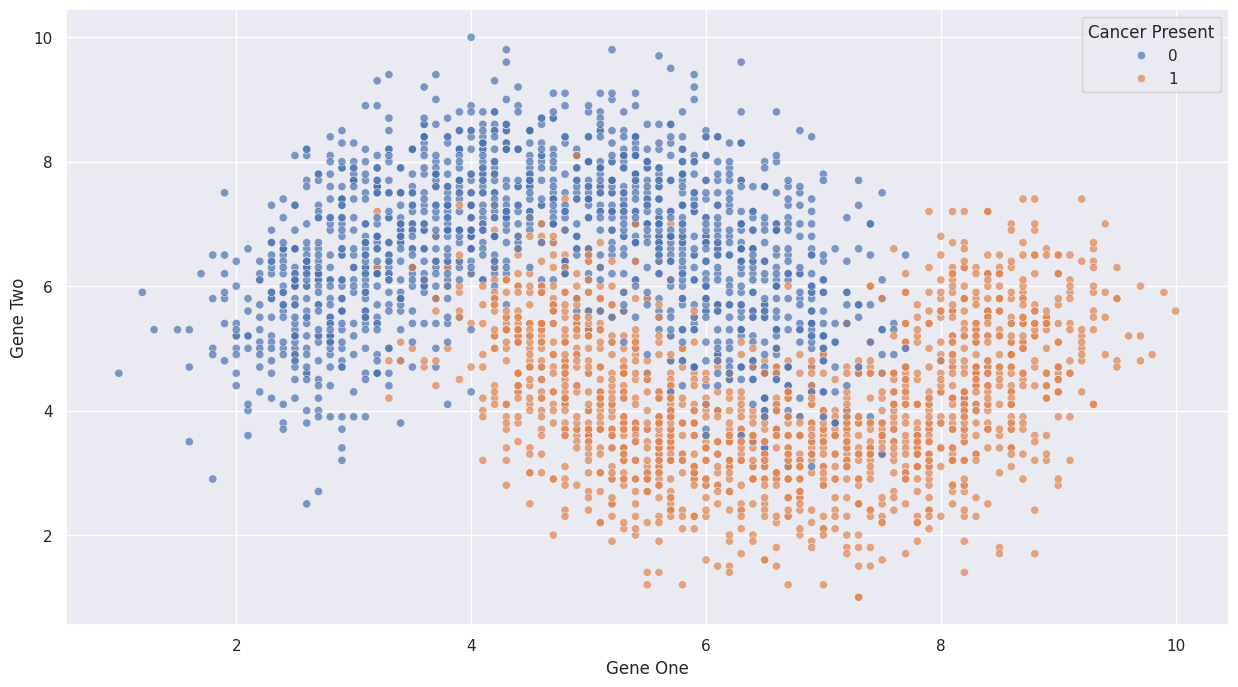

In [ ]:
# Set the default plot size for seaborn/matplotlib figures.
# This makes the scatter plot easier to read (especially labels and class separation).
sns.set(rc={'figure.figsize': (15, 8)})

# Visualise the dataset in 2D using the two gene-expression features.
# Each point is one patient/sample, the colour (hue) shows the class label: whether cancer is present.
# alpha adds transparency so overlapping points are easier to see (reveals density).
sns.scatterplot(x='Gene One', y='Gene Two', hue='Cancer Present', data=df, alpha=0.7)


## Train|Test Split and Scaling Data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# Separate features (inputs) from the target (label).
# X contains only the predictor columns (here: gene expression features).
# y contains the class we want to predict: whether cancer is present.
X = df.drop('Cancer Present', axis=1)
y = df['Cancer Present']

In [ ]:
# Split the dataset into training and test sets.
# - We train the model on (X_train, y_train).
# - We evaluate generalisation performance on (X_test, y_test), which the model does not see during training.
# test_size=0.3 keeps 30% of the data for testing (70% for training).
# random_state=42 fixes the shuffle so you get the same split every run (reproducibility).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
# Create a standardisation object.
# StandardScaler transforms each feature to have mean = 0 and standard deviation = 1 (based on the training set).
# This is important for KNN because it uses distances, features with larger scales would otherwise dominate.
scaler = StandardScaler()


In [ ]:
# Fit the scaler on the training data ONLY, then transform the training data.
# This learns the training-set mean and standard deviation, then standardises X_train.
# We do this to avoid "data leakage", the test set must not influence preprocessing.
scaled_X_train = scaler.fit_transform(X_train)

# Transform the test data using the SAME scaler parameters learned from the training set.
# Never use fit_transform on X_test, that would leak information from the test set.
scaled_X_test = scaler.transform(X_test)


## <b>✅ K-NN Model Development</b>

<div class="box">
  <div class="boxtitle"><span class="badge b-info">🧱</span> What we are building</div>
  <ul>
    <li>
      We will train a <b>KNN classifier</b> to predict <code>Cancer Present</code> from the two gene-expression features.
      KNN is a <b>distance-based</b> method, it predicts a label by looking at the <b>k closest</b> training samples.
    </li>
    <li>
      In practice, “model development” for KNN is mostly about:
      <ul>
        <li>choosing a sensible <code>k</code>,</li>
        <li>choosing how distance is computed (metric),</li>
        <li>scaling features correctly,</li>
        <li>evaluating properly on unseen data.</li>
      </ul>
    </li>
  </ul>
</div>

<div class="box info">
  <div class="boxtitle"><span class="badge b-info">⚙️</span> Step-by-step workflow</div>
  <ol>
    <li>
      <b>Define X and y</b><br>
      <span style="color:#334155;">
        <code>X</code> contains the input features (<code>Gene One</code>, <code>Gene Two</code>), and <code>y</code> is the class label (<code>Cancer Present</code>).
      </span>
    </li>
    <li>
      <b>Train/test split</b><br>
      <span style="color:#334155;">
        We split the data so we can measure generalisation. The test set must be “unseen” during training and tuning.
      </span>
    </li>
    <li>
      <b>Scale the features (critical for KNN)</b><br>
      <span style="color:#334155;">
        KNN compares distances. If one feature has a larger numeric range, it dominates the distance calculation.
        We use <b>StandardScaler</b> (mean 0, std 1), and we fit it on the training set only to avoid leakage.
      </span>
    </li>
    <li>
      <b>Choose hyperparameters</b><br>
      <span style="color:#334155;">
        The most important hyperparameter is <code>n_neighbors = k</code>.
        We can start with a default (e.g., 5) and then tune it using cross-validation.
      </span>
    </li>
    <li>
      <b>Fit the model</b><br>
      <span style="color:#334155;">
        KNN “fits” quickly, it mainly stores the scaled training data internally.
      </span>
    </li>
    <li>
      <b>Evaluate</b><br>
      <span style="color:#334155;">
        We compute accuracy and inspect a <b>confusion matrix</b> to see false positives and false negatives.
      </span>
    </li>
  </ol>
</div>

<div class="box">
  <div class="boxtitle"><span class="badge b-info">📌</span> Key hyperparameters (what they mean)</div>
  <ul>
    <li>
      <b><code>n_neighbors (k)</code></b>:
      number of neighbours used for voting.
      Smaller values can overfit, larger values can underfit.
    </li>
    <li>
      <b><code>metric</code></b>:
      how distance is measured, typically <code>euclidean</code> for continuous features.
      (In high dimensions, distance behaviour can change, but here we keep it simple.)
    </li>
    <li>
      <b><code>weights</code></b>:
      <code>uniform</code> gives each neighbour equal vote,
      <code>distance</code> gives closer points more influence (often helps when classes overlap).
    </li>
  </ul>
</div>

<div class="box warn">
  <div class="boxtitle"><span class="badge b-warn">⚠️</span> Common mistakes to avoid</div>
  <ul>
    <li>
      <b>Scaling the full dataset before splitting</b>, this leaks information from the test set.
      Always fit the scaler on <b>training only</b>.
    </li>
    <li>
      <b>Tuning k using the test set</b>, this turns the test set into part of training.
      Use cross-validation on the training set, then test once.
    </li>
    <li>
      <b>Reporting only accuracy</b>, accuracy can hide important errors.
      Always check a confusion matrix so you can see which class is being misclassified.
    </li>
  </ul>
</div>

<div class="box ok">
  <div class="boxtitle"><span class="badge b-ok">✅</span> What you should be able to explain after this section</div>
  <ul>
    <li>Why KNN needs scaled features.</li>
    <li>What happens when <code>k</code> is too small vs too large.</li>
    <li>How we fairly evaluate a classifier using a held-out test set.</li>
  </ul>
</div>


In [ ]:
# Create a KNN classifier with k = 1 (1-nearest neighbour).
# This means each new sample is classified using ONLY the single closest training point.
# k=1 often gives a very flexible boundary (can overfit noise), but it is a useful baseline to start with.
knn_model = KNeighborsClassifier(n_neighbors=1)


In [ ]:
# Train (fit) the KNN model using the scaled training data.
# For KNN, "fitting" mainly stores the training points and their labels,
# so that future predictions can be made by finding the nearest neighbours in this space.
knn_model.fit(scaled_X_train, y_train)


KNeighborsClassifier(n_neighbors=1)

In [ ]:
# Combine the test features (X_test) and the true test labels (y_test) into a single DataFrame.
# This is convenient for inspection, debugging, and comparing predictions against the ground truth.
# axis=1 concatenates column-wise, so each row corresponds to one test sample with its label.
full_test = pd.concat([X_test, y_test], axis=1)


In [ ]:
# Number of samples (rows) in the test set.
# This should be approximately 30% of the original dataset because test_size=0.3.
len(full_test)

900

<Axes: xlabel='Gene One', ylabel='Gene Two'>

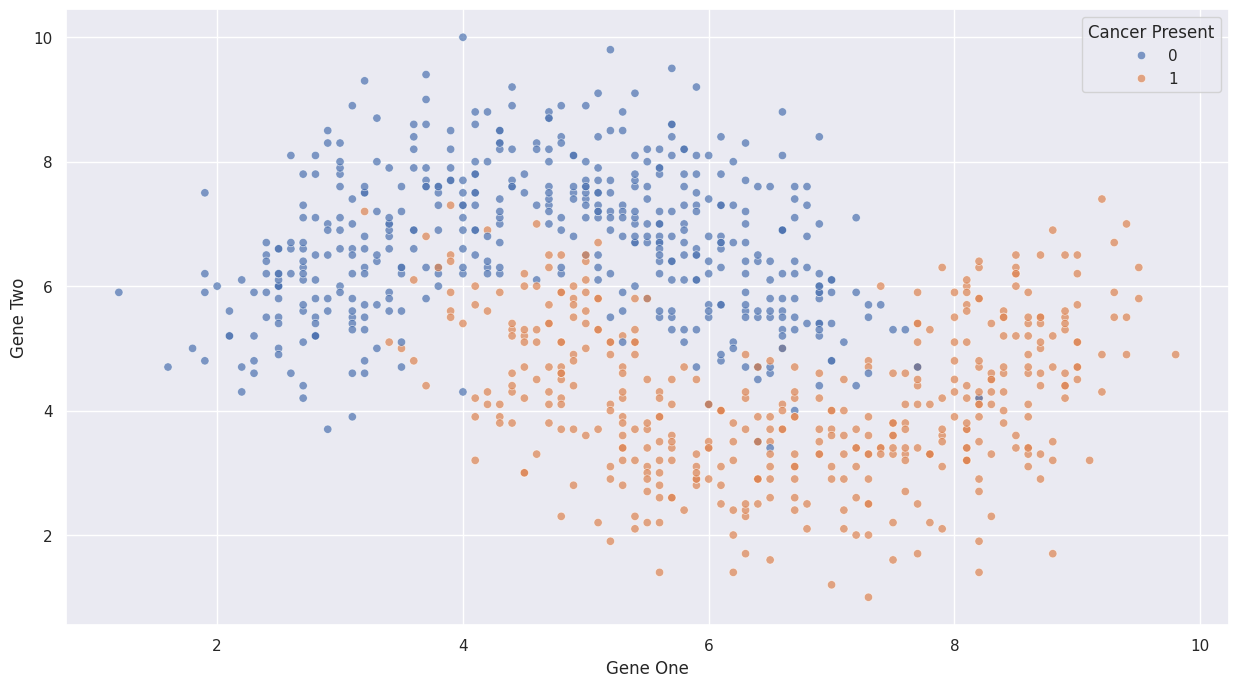

In [ ]:
# Visualise ONLY the test set in feature space (Gene One vs Gene Two).
# Each point is a test sample, coloured by the true label (Cancer Present).
# This helps you see whether the test data is separable, overlapping, or clustered,
# which often explains why the classifier performs well or poorly.
sns.scatterplot(
    x='Gene One', y='Gene Two',
    hue='Cancer Present',
    data=full_test,
    alpha=0.7
)


## <b>✅ Model Evaluation</b>

<div class="box">
  <div class="boxtitle"><span class="badge b-info">🧭</span> Core idea</div>
  <ul>
    <li>
      After training a model, we need to check whether it <b>generalises</b>.
      That means it should perform well on <b>unseen data</b>, not just the training set.
    </li>
    <li>
      We evaluate using the <b>test set</b> (<code>X_test</code>, <code>y_test</code>), which was held out during training.
      This gives a more realistic estimate of how the model would perform on new patients/samples.
    </li>
    <li>
      For classification, we do not rely on a single number.
      We typically examine:
      <b>accuracy</b>, a <b>confusion matrix</b>, and (when relevant) <b>precision</b>, <b>recall</b>, and <b>F1-score</b>.
    </li>
  </ul>
</div>

<div class="box info">
  <div class="boxtitle"><span class="badge b-info">📌</span> What we compute (and why)</div>
  <ul>
    <li>
      <b>Predictions</b>:
      we first compute <code>y_pred</code>, the model’s predicted labels for the test set.
      Everything else is based on comparing <code>y_pred</code> vs <code>y_test</code>.
    </li>
    <li>
      <b>Accuracy</b>:
      the proportion of correct predictions.
      Useful as a quick summary, but can be misleading if classes are imbalanced.
    </li>
    <li>
      <b>Confusion matrix</b>:
      shows <b>what types of errors</b> the model makes.
      For binary classification, this splits outcomes into:
      <ul>
        <li><b>True Positive (TP)</b>, predicted cancer, cancer present</li>
        <li><b>True Negative (TN)</b>, predicted no cancer, no cancer</li>
        <li><b>False Positive (FP)</b>, predicted cancer, but actually no cancer</li>
        <li><b>False Negative (FN)</b>, predicted no cancer, but actually cancer present</li>
      </ul>
      In many medical contexts, <b>false negatives</b> can be more costly than false positives, so we pay attention to both.
    </li>
    <li>
      <b>Classification report</b> (optional but recommended):
      includes <b>precision</b>, <b>recall</b>, and <b>F1-score</b> per class.
      These help when the dataset is imbalanced or when one error type matters more.
    </li>
  </ul>
</div>

<div class="box warn">
  <div class="boxtitle"><span class="badge b-warn">⚠️</span> Two evaluation pitfalls</div>
  <ul>
    <li>
      <b>Do not tune <code>k</code> using the test set</b>.
      If you repeatedly change <code>k</code> based on test accuracy, you are indirectly training on the test set.
      The correct approach is <b>cross-validation on the training set</b>, then test once.
    </li>
    <li>
      <b>Check scaling and leakage</b>.
      The scaler must be fitted on <code>X_train</code> only, then applied to <code>X_test</code>.
      Leakage typically inflates results.
    </li>
  </ul>
</div>

<div class="box task">
  <div class="boxtitle"><span class="badge b-task">🧩</span> What you will do in code</div>
  <ul>
    <li>Generate test predictions: <code>y_pred = knn_model.predict(scaled_X_test)</code></li>
    <li>Compute accuracy: <code>accuracy_score(y_test, y_pred)</code></li>
    <li>Compute and plot the confusion matrix (and interpret FP vs FN)</li>
    <li>(Optional) Print a classification report to see precision/recall/F1</li>
  </ul>
</div>

<div class="box ok">
  <div class="boxtitle"><span class="badge b-ok">✅</span> What “good” evaluation looks like</div>
  <ul>
    <li>
      You can explain the difference between training performance and test performance,
      and why we trust the test score more.
    </li>
    <li>
      You can interpret the confusion matrix and describe what kinds of mistakes the model is making.
    </li>
    <li>
      You can justify why accuracy alone is not always enough, especially for high-stakes classification problems.
    </li>
  </ul>
</div>


In [ ]:
# Predict class labels for the (scaled) test set.
# The model looks at the k nearest training samples (here k=1) for each test point
# and assigns the majority class (for k=1, it simply copies the label of the single closest neighbour).
# y_pred will be an array/Series of predicted labels, same length as y_test.
y_pred = knn_model.predict(scaled_X_test)


In [ ]:
# Import common classification evaluation metrics:
# - accuracy_score: overall fraction of correct predictions
# - confusion_matrix: counts of TP/TN/FP/FN (for binary classification)
# - classification_report: precision/recall/F1 per class + support
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Compute accuracy on the test set:
# accuracy = (number of correct predictions) / (total number of test samples)
# Note: accuracy can be misleading if classes are imbalanced, so we also check a confusion matrix and report.
accuracy_score(y_test, y_pred)


0.8911111111111111

In [ ]:
# Compute the confusion matrix for the test set.
# For binary classification, the default layout is:
# [[TN, FP],
#  [FN, TP]]
# where:
# - TN: predicted 0 and actually 0 (correct negative)
# - FP: predicted 1 but actually 0 (false alarm)
# - FN: predicted 0 but actually 1 (missed positive)
# - TP: predicted 1 and actually 1 (correct positive)
confusion_matrix(y_test, y_pred)


array([[422,  48],
       [ 50, 380]])

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.90      0.90       470
           1       0.89      0.88      0.89       430

    accuracy                           0.89       900
   macro avg       0.89      0.89      0.89       900
weighted avg       0.89      0.89      0.89       900



## <b>✅ Hyperparameter Selection</b>

<div class="box">
  <div class="boxtitle"><span class="badge b-info">🧭</span> Core idea</div>
  <ul>
    <li>
      A <b>hyperparameter</b> is a setting we choose <b>before</b> training, it is not learned from data like model parameters.
      For KNN, the most important hyperparameter is <code>n_neighbors = k</code>.
    </li>
    <li>
      If we choose <code>k</code> poorly, the model may:
      <ul>
        <li><b>overfit</b> (too small <code>k</code>, very sensitive to noise), or</li>
        <li><b>underfit</b> (too large <code>k</code>, decision boundary becomes too smooth).</li>
      </ul>
    </li>
    <li>
      We should select hyperparameters using <b>cross-validation on the training set</b>,
      then evaluate <b>once</b> on the held-out test set.
      This keeps the test set as a fair estimate of generalisation.
    </li>
  </ul>
</div>

<div class="box info">
  <div class="boxtitle"><span class="badge b-info">🧪</span> What we tune for KNN</div>
  <ul>
    <li>
      <b><code>n_neighbors</code> (k)</b>:
      how many neighbours vote. This is the main lever for the bias–variance trade-off.
    </li>
    <li>
      <b><code>weights</code></b>:
      <code>uniform</code> (equal vote) vs <code>distance</code> (closer points count more).
      Distance weighting can help if the boundary is messy or if classes overlap.
    </li>
    <li>
      <b><code>metric</code></b> (optional here):
      typically <code>euclidean</code> for continuous features.
      We keep it simple in this tutorial and focus on tuning <code>k</code> first.
    </li>
  </ul>
</div>

<div class="box">
  <div class="boxtitle"><span class="badge b-info">📌</span> Proper workflow (no leakage)</div>
  <ol>
    <li>
      <b>Keep the test set untouched</b>.
      We will not use it to choose <code>k</code>.
    </li>
    <li>
      <b>Use a pipeline</b>:
      scaling must happen <b>inside</b> cross-validation so each fold is scaled using only its training portion.
      This prevents leakage and gives a realistic score.
    </li>
    <li>
      <b>Run GridSearchCV</b> to test multiple values of <code>k</code> (and optionally <code>weights</code>),
      then pick the best performing setting based on cross-validation score.
    </li>
    <li>
      <b>Evaluate the best model</b> on the held-out test set exactly once.
    </li>
  </ol>
</div>

<div class="box task">
  <div class="boxtitle"><span class="badge b-task">🧩</span> What you will do in code</div>
  <ul>
    <li>
      Define a search grid for <code>n_neighbors</code> (e.g., 1 to 30).
    </li>
    <li>
      Fit <b>GridSearchCV</b> on the training data (with a pipeline that includes scaling).
    </li>
    <li>
      Inspect <code>best_params_</code> and <code>best_score_</code>.
    </li>
    <li>
      Predict on the test set using the best estimator and re-check accuracy and confusion matrix.
    </li>
  </ul>
</div>

<div class="box warn">
  <div class="boxtitle"><span class="badge b-warn">⚠️</span> Common mistakes</div>
  <ul>
    <li>
      <b>Picking k based on test accuracy</b>, this is effectively tuning on the test set.
      Your reported performance becomes optimistic and unreliable.
    </li>
    <li>
      <b>Scaling outside cross-validation</b>.
      If you scale the full training set before CV, folds can “see” information they should not.
      A pipeline prevents this.
    </li>
  </ul>
</div>

<div class="box ok">
  <div class="boxtitle"><span class="badge b-ok">✅</span> What you should be able to explain</div>
  <ul>
    <li>Why <code>k</code> is a hyperparameter and how it affects model complexity.</li>
    <li>Why cross-validation is used for hyperparameter selection.</li>
    <li>Why the test set must remain untouched until the very end.</li>
  </ul>
</div>


### A - Elbow Method for Choosing Reasonable K Values

NOTE: This uses the test set for the hyperparameter selection of K.

In [ ]:
# We will test multiple values of k (number of neighbours) and record the test error for each one.
# test_error_rates will store the error rate (1 - accuracy) for k = 1, 2, ..., 29.
test_error_rates = []

for k in range(1, 30):
    # Create a KNN model with the current k
    knn_model = KNeighborsClassifier(n_neighbors=k)

    # Fit the model on the scaled training data
    knn_model.fit(scaled_X_train, y_train)

    # Predict labels for the scaled test data
    y_pred_test = knn_model.predict(scaled_X_test)

    # Compute test error rate: proportion of incorrect predictions on the test set
    # error = 1 - accuracy
    test_error = 1 - accuracy_score(y_test, y_pred_test)

    # Store the error rate so we can plot error vs k and pick a reasonable k
    test_error_rates.append(test_error)

# Note: This uses the test set to compare k values, which is fine for learning,
# but in a real workflow you should choose k using cross-validation on the training set,
# then evaluate once on the test set.



Text(0.5, 0, 'K Value')

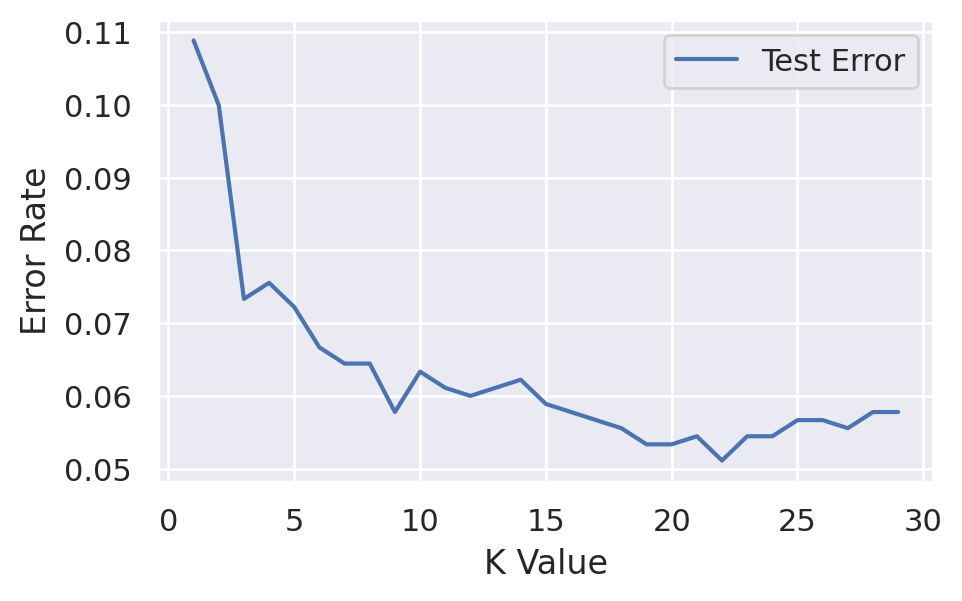

In [ ]:
# Create a new figure for the error-rate curve.
# figsize controls the plot size in inches, dpi controls image sharpness (higher = crisper).
plt.figure(figsize=(5, 3), dpi=200)

# Plot test error rate against k.
# x-axis: k values (1 to 29)
# y-axis: error rate (1 - accuracy) for each k
plt.plot(range(1, 30), test_error_rates, label='Test Error')

# Show the legend so we know what the line represents.
plt.legend()

# Label axes clearly so the plot is interpretable.
plt.ylabel('Error Rate')
plt.xlabel('K Value')


### B - Full Cross Validation Grid Search for K Value

## Creating a Pipeline to find K value

We'll use a Pipeline object to set up a workflow of operations:

* Step 0: The data are split into TRAINING data and TEST data according to the cv parameter that you specified in the GridSearchCV.
* Step 1: the scaler is fitted on the TRAINING data
* Step 2: the scaler transforms TRAINING data
* Step 3: the models are fitted/trained using the transformed TRAINING data
* Step 4: the scaler is used to transform the TEST data
* Step 5: the trained models predict using the transformed TEST data

In [ ]:
scaler = StandardScaler()
knn = KNeighborsClassifier()

In [ ]:
knn.get_params().keys()

dict_keys(['algorithm', 'leaf_size', 'metric', 'metric_params', 'n_jobs', 'n_neighbors', 'p', 'weights'])

In [ ]:
operations = [('scaler',scaler),('knn',knn)]
print(operations)

[('scaler', StandardScaler()), ('knn', KNeighborsClassifier())]


In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
pipe = Pipeline(operations)
print(pipe)

Pipeline(steps=[('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
k_values = list(range(1,30))
param_grid = {'knn__n_neighbors': k_values}
print(param_grid)

{'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]}


In [ ]:
# Set up a full cross-validation search over the hyperparameter grid.
# GridSearchCV will:
# - try every combination in param_grid,
# - run 5-fold cross-validation (cv=5) on the training data,
# - score each setting using accuracy,
# - and keep the best-performing configuration.
full_cv_classifier = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')

# Fit the grid search on the TRAINING data only.
# Important: we pass X_train (unscaled) because the Pipeline (pipe) handles scaling internally.
# This prevents data leakage, each CV fold fits the scaler only on its training split.
full_cv_classifier.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                              12, 13, 14, 15, 16, 17, 18, 19,
                                              20, 21, 22, 23, 24, 25, 26, 27,
                                              28, 29]},
             scoring='accuracy')

In [ ]:
# Inspect the parameters of the best model found by GridSearchCV.
# best_estimator_ is the pipeline configured with the best hyperparameters (e.g., best k, weights, etc.).
# get_params() prints all parameters in the pipeline, including:
# - the scaler settings, and
# - the KNN settings (e.g., n_neighbors, weights, metric).
full_cv_classifier.best_estimator_.get_params()


{'memory': None,
 'steps': [('scaler', StandardScaler()),
  ('knn', KNeighborsClassifier(n_neighbors=22))],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'knn': KNeighborsClassifier(n_neighbors=22),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'knn__algorithm': 'auto',
 'knn__leaf_size': 30,
 'knn__metric': 'minkowski',
 'knn__metric_params': None,
 'knn__n_jobs': None,
 'knn__n_neighbors': 22,
 'knn__p': 2,
 'knn__weights': 'uniform'}

In [ ]:
# Retrieve the mean cross-validation accuracy for each hyperparameter setting tested.
# cv_results_ is a dictionary containing detailed results from GridSearchCV.
# 'mean_test_score' is the average CV score across the 5 folds for each parameter combination,
# in the same order as cv_results_['params'].
full_cv_classifier.cv_results_['mean_test_score']


array([0.90428571, 0.90619048, 0.92095238, 0.91333333, 0.92428571,
       0.92047619, 0.92428571, 0.92571429, 0.9247619 , 0.92238095,
       0.9247619 , 0.92380952, 0.92809524, 0.92857143, 0.92809524,
       0.92904762, 0.92857143, 0.92857143, 0.92714286, 0.93      ,
       0.92761905, 0.93095238, 0.92761905, 0.92761905, 0.92714286,
       0.92714286, 0.92809524, 0.92904762, 0.93      ])

## Final Model

We just saw that our  GridSearch recommends a K= 22 (in line with our alternative Elbow Method). Let's now use the PipeLine again, but this time, no need to do a grid search, instead we will evaluate on our hold-out Test Set.

In [ ]:
scaler = StandardScaler()
knn22 = KNeighborsClassifier(n_neighbors=22)
operations = [('scaler',scaler),('knn22',knn22)]

In [ ]:
pipe = Pipeline(operations)
pipe.fit(X_train,y_train)
pipe_pred = pipe.predict(X_test)

In [ ]:
accuracy_score(y_test,pipe_pred)

0.9488888888888889

In [ ]:
print(classification_report(y_test,pipe_pred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       470
           1       0.96      0.93      0.95       430

    accuracy                           0.95       900
   macro avg       0.95      0.95      0.95       900
weighted avg       0.95      0.95      0.95       900



In [ ]:
confusion_matrix(y_test,pipe_pred)

array([[452,  18],
       [ 28, 402]])

## 2) ✅ K-means clustering

K Means algorithm is an unsupervised learning algorithm, ie. it needs no training data, it performs the computation on the actual dataset. This should be apparent from the fact that in K Means, we are just trying to group similar data points into clusters, there is no prediction involved.

**k-Means Clustering works:**




1.   The K Means algorithm is iterative based, it repeatedly calculates the cluster centroids, refining the values until they do not change much. The k-means algorithm takes a dataset of ‘n’ points as input, together with an integer parameter ‘k’ specifying how many clusters to create (supplied by the programmer). The output is a set of ‘k’ cluster centroids and a labeling of the dataset that maps each of the data points to a unique cluster.
2.   k centroids in the dataset. Then it calculates the distance of each point to each centroid. Each centroid represents a cluster and the points closest to the centroid are assigned to the cluster.

3. The centroid values are recalculated, usually taking the arithmetic mean of all points in the cluster.

4. After the new values of centroid are found, the algorithm performs the same set of steps over and over again until the differences between old centroids and the new centroids are negligible.

## Dataset

We'll use the Iris flower dataset to study some of the clustering algorithms available in scikit-learn. It contains various measurements for 150 flowers belonging to 3 different species.

In [ ]:
iris_df = sns.load_dataset('iris')
iris_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


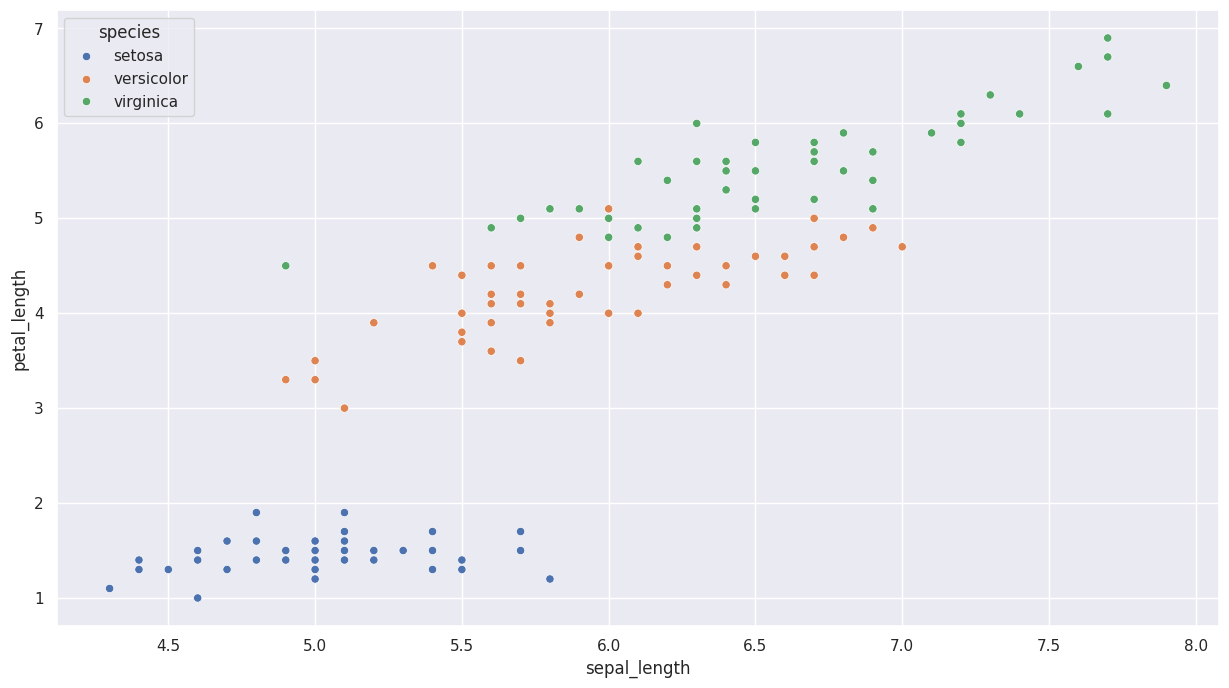

In [ ]:
sns.scatterplot(data=iris_df, x='sepal_length', y='petal_length', hue='species');

We'll attempt to cluster observations using numeric columns in the data.


In [ ]:
numeric_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
X = iris_df[numeric_cols]

## K-means Model Development

Let's apply K-means clustering to the Iris dataset.



In [ ]:
from sklearn.cluster import KMeans

In [ ]:
model = KMeans(n_clusters=3, random_state=42)
model.fit(X)

KMeans(n_clusters=3, random_state=42)

We can check the cluster centers for each cluster.



In [ ]:
model.cluster_centers_

array([[6.85384615, 3.07692308, 5.71538462, 2.05384615],
       [5.006     , 3.428     , 1.462     , 0.246     ],
       [5.88360656, 2.74098361, 4.38852459, 1.43442623]])

We can now classify points using the model.



In [ ]:
preds = model.predict(X)
preds

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0,
       0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 2], dtype=int32)

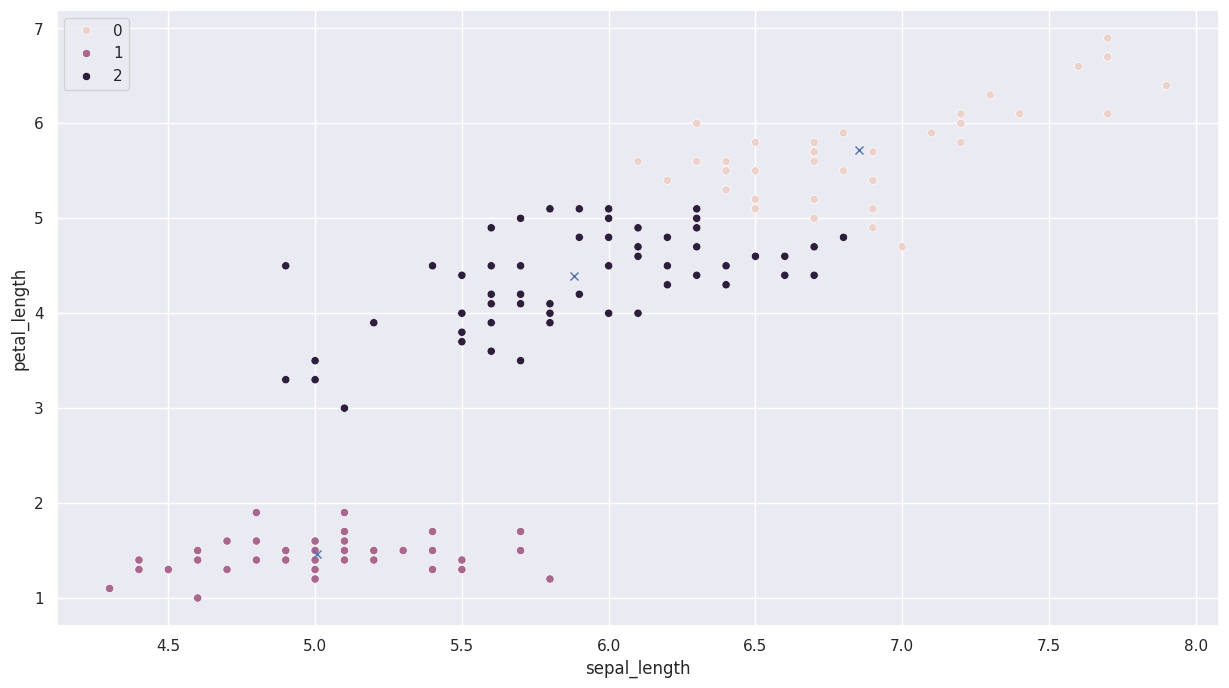

In [ ]:
sns.scatterplot(data=X, x='sepal_length', y='petal_length', hue=preds);
centers_x, centers_y = model.cluster_centers_[:,0], model.cluster_centers_[:,2]
plt.plot(centers_x, centers_y, 'xb')

As you can see, K-means algorithm was able to classify (for the most part) different specifies of flowers into separate clusters. Note that we did not provide the "species" column as an input to KMeans.

We can check the "goodness" of the fit by looking at model.inertia_, which contains the sum of squared distances of samples to their closest cluster center. Lower the inertia, better the fit.

In [ ]:
model.inertia_

78.85566582597727

Let's try creating 6 clusters.

In [ ]:
model = KMeans(n_clusters=6, random_state=42).fit(X)
preds = model.predict(X)
preds

array([1, 5, 5, 5, 1, 1, 5, 1, 5, 5, 1, 5, 5, 5, 1, 1, 1, 1, 1, 1, 1, 1,
       5, 1, 5, 5, 1, 1, 1, 5, 5, 1, 1, 1, 5, 5, 1, 1, 5, 1, 1, 5, 5, 1,
       1, 5, 1, 5, 1, 5, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2, 2, 2, 2, 0, 2, 0,
       2, 2, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 0, 2, 0, 0, 0,
       2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 4, 0, 3, 4, 4, 3, 2, 3, 4, 3,
       4, 4, 4, 0, 4, 4, 4, 3, 3, 0, 4, 0, 3, 0, 4, 3, 0, 0, 4, 3, 3, 3,
       4, 0, 0, 3, 4, 4, 0, 4, 4, 4, 0, 4, 4, 4, 0, 4, 4, 0], dtype=int32)

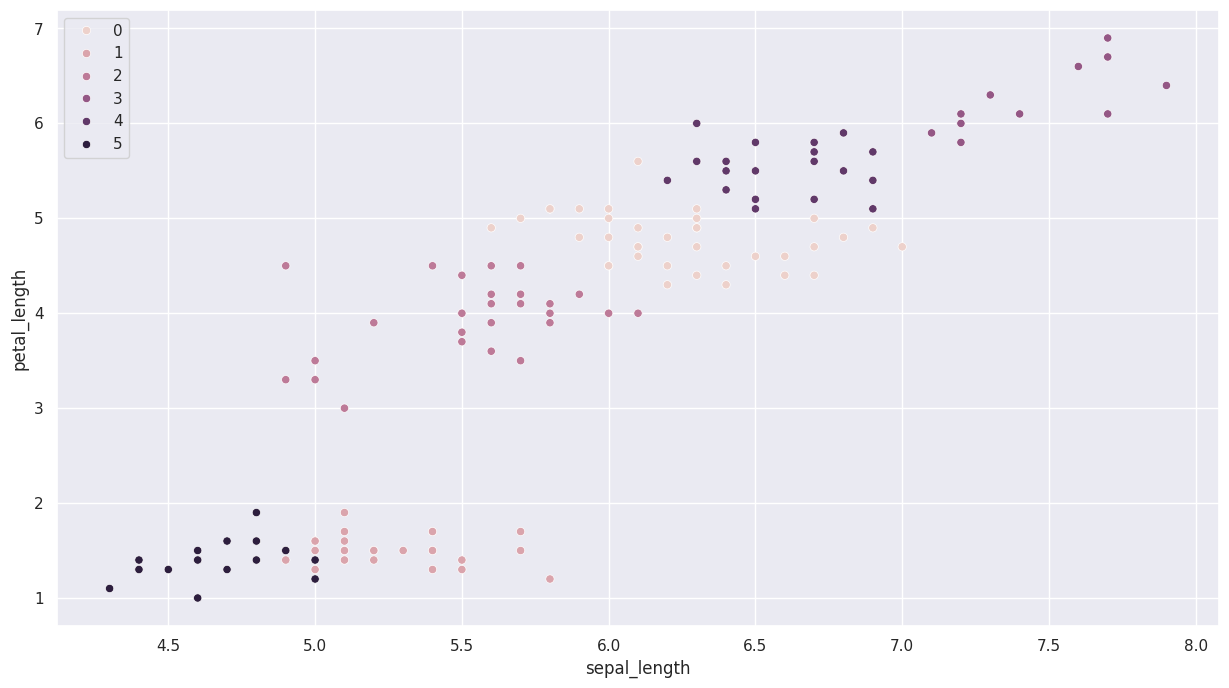

In [ ]:
sns.scatterplot(data=X, x='sepal_length', y='petal_length', hue=preds);


In [ ]:
model.inertia_

39.066035353535376

## Elbow Method for Choosing Reasonable K Values

In most real-world scenarios, there's no predetermined number of clusters. In such a case, you can create a plot of "No. of clusters" vs "Inertia" to pick the right number of clusters.

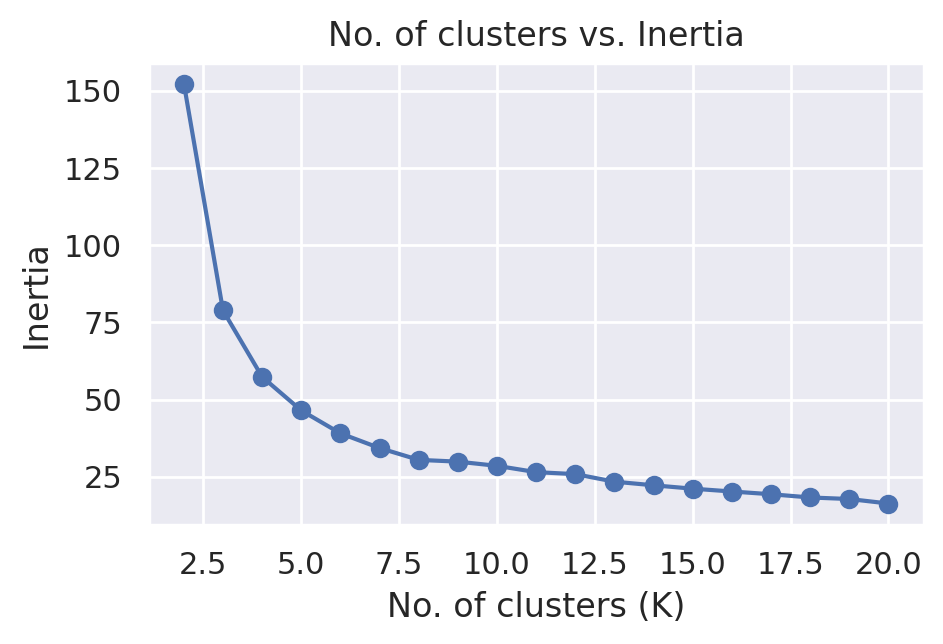

In [ ]:
options = range(2,21)
inertias = []

for n_clusters in options:
    model = KMeans(n_clusters, random_state=42).fit(X)
    inertias.append(model.inertia_)
plt.figure(figsize=(5,3),dpi=200)
plt.title("No. of clusters vs. Inertia")
plt.plot(options, inertias, '-o')
plt.xlabel('No. of clusters (K)')
plt.ylabel('Inertia');

The chart is creates an "elbow" plot, and you can pick the number of clusters beyond which the reduction in inertia decreases sharply.

Mini Batch K Means: The K-means algorithm can be quite slow for really large dataset. Mini-batch K-means is an iterative alternative to K-means that works well for large datasets. Learn more about it here: https://scikit-learn.org/stable/modules/clustering.html#mini-batch-kmeans

## 3) ✅ Exercises



<div class="box task">
  <div class="boxtitle"><span class="badge b-task">📝</span> Exercise 1, clustering on the Bank Marketing dataset</div>
  <p>Perform clustering on the <b>Bank Marketing</b> dataset available on the VLE. Choose a reasonable number of clusters and interpret what each segment represents.</p>
  <ul>
    <li>Preprocess appropriately (handle categorical variables, scale numerical features).</li>
    <li>Use an elbow-style diagnostic (or similar) to justify your <code>k</code>.</li>
    <li>Summarise clusters with cluster-wise statistics and short interpretations.</li>
  </ul>
</div>


In [ ]:
# TODO (Exercise 1): load the Bank Marketing dataset from your Colab/Drive/VLE download
# 1) Preprocess (encoding + scaling)
# 2) Fit KMeans for a range of k
# 3) Choose k, then fit final model and interpret clusters

import pandas as pd
import numpy as np

# df_bank = pd.read_csv("...")


<details>
<summary><b>✅ Suggested approach (click to expand)</b></summary>

- Use <code>ColumnTransformer</code> with <code>OneHotEncoder(handle_unknown="ignore")</code> for categoricals and <code>StandardScaler</code> for numericals.
- Fit <code>KMeans</code> for <code>k</code> in, say, 2–10 and plot inertia (or silhouette) to select a reasonable value.
- After fitting your final model, add a <code>cluster</code> column and compute cluster-wise means/medians for key numeric fields, plus value counts for key categoricals.
- Your interpretation should read like, “Cluster A has higher balance and longer call duration, Cluster B has lower balance and short calls”, etc.

</details>


<div class="box task">
  <div class="boxtitle"><span class="badge b-task">🧪</span> Exercise 2, classification on the Sonar dataset with Pipeline + GridSearchCV</div>
  <p>Perform classification on the <b>Sonar</b> dataset available on the VLE. Use a <b>Pipeline</b> and <b>GridSearchCV</b> so your workflow can be reused for other models.</p>
  <ul>
    <li>Split into train/test, keep the test set untouched until the end.</li>
    <li>Include scaling in the pipeline (do not scale before splitting).</li>
    <li>Report accuracy plus at least one other metric (confusion matrix, precision/recall, F1).</li>
  </ul>
</div>


In [ ]:
# TODO (Exercise 2): pipeline + grid search on Sonar
# 1) Load data
# 2) Train/test split
# 3) Pipeline (scaler + model)
# 4) GridSearchCV and evaluation on the test set

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# df_sonar = pd.read_csv("...")


<details>
<summary><b>✅ Suggested approach (click to expand)</b></summary>

- Use a pipeline like: <code>Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])</code>.
- Grid search over <code>knn__n_neighbors</code>, optionally <code>knn__weights</code> and <code>knn__p</code>.
- Fit <code>GridSearchCV(..., cv=5)</code> on the training set only, then evaluate the best estimator on the held-out test set.
- Report confusion matrix and <code>classification_report</code>, not just accuracy.

</details>


## <b>✅ Week 6 Tutorial Complete</b>

<p>
  This concludes <b>Week 6, Supervised Learning (Classification) and Unsupervised Learning</b>.
  You should now be able to build a complete <b>KNN classification</b> workflow, define <code>X</code> and <code>y</code>,
  perform a proper <b>train/test split</b>, apply <b>standardisation</b> correctly (fit on training only, transform test),
  and evaluate performance using <b>accuracy</b> and a <b>confusion matrix</b>.
  You should also be able to justify the impact of the key hyperparameter <code>k</code>, and select it more reliably using
  <b>cross-validation</b> with <b>pipelines</b> (to avoid data leakage).
  Finally, you should be able to explain the purpose of <b>unsupervised learning</b>, and apply <b>K-means clustering</b>
  to identify structure in unlabeled data and interpret clusters in a meaningful way.
</p>
